# Data understanding  

Netflix is one of the largest streaming platforms in the world.  
It Offers a wide variety of movies and TV shows across different genres and countries.  
Understanding the characteristics of the available content can provide insights into trends,  
popular genres, and the distribution of content over time.

This project performs an Exploratory Data Analysis (EDA) on a Netflix dataset to understand the structure of the data and identify patterns in the content.

## Data 

Downloading the data from file.  

In [181]:
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

warnings.simplefilter(action='ignore', category=FutureWarning)

df = pd.read_csv("data/netflix_titles.csv")
df.head(3)


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...


##### Understanding the dataset

Checking the shape, showing row and column count.  

In [182]:
df.shape

(8807, 12)

Printing column names in the dataframe.  

In [183]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

Printing basic information; column index, name, non-null count and datatype.  


In [184]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


Checking for missing values.  

In [185]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

##### Preprocessing the data;
* drop duplicates
* handle missing values
    * fill with 'unknown'
* date_added to date-time format
* Add extra columns for 
    * date_added
    * month_added
    * year_added
* delete rows with missing dates

* There is 2634 missing from 'director' but for this project I won't delete the column.

In [186]:
df.drop_duplicates()

df['director'] = df['director'].fillna("Unknown")
df['cast'] = df['cast'].fillna("Unknown")
df['country'] = df['country'].fillna("Unknown")

df['date_added'] = df['date_added'].str.strip()
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month
df['day_added'] = df['date_added'].dt.day

df = df.dropna(subset=['year_added'])
df['year_added'] = df['year_added'].astype(int)
df.shape

(8797, 15)

####  Visualizing the data



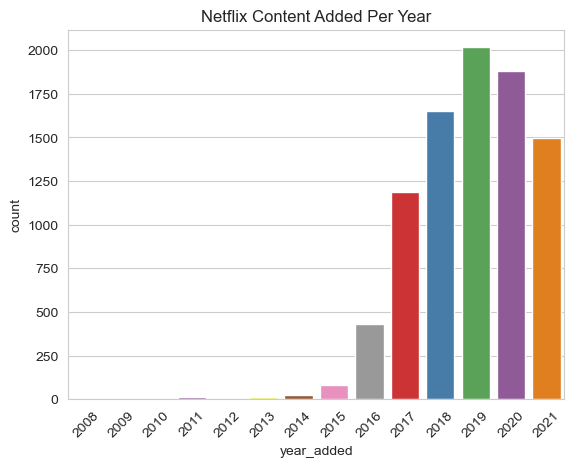

In [187]:
sns.countplot(x='year_added', data=df, palette="Set1")
plt.xticks(rotation=45)
plt.title("Netflix Content Added Per Year")
plt.show()

##### The most content was added in 2019. 

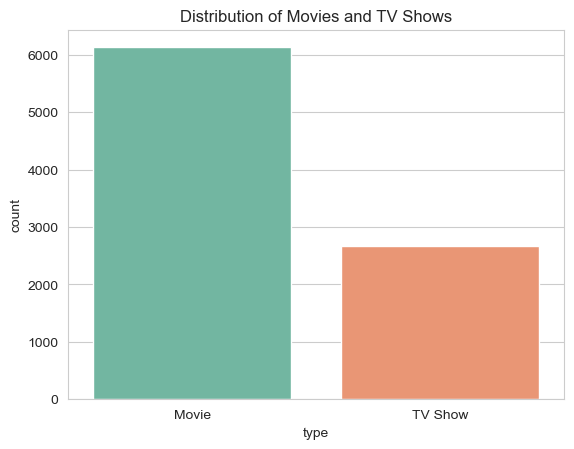

In [188]:

sns.countplot(x='type', data=df, palette="Set2")
plt.title("Distribution of Movies and TV Shows")
plt.show()

##### There is almost double the amount of movies compared to TV Shows.

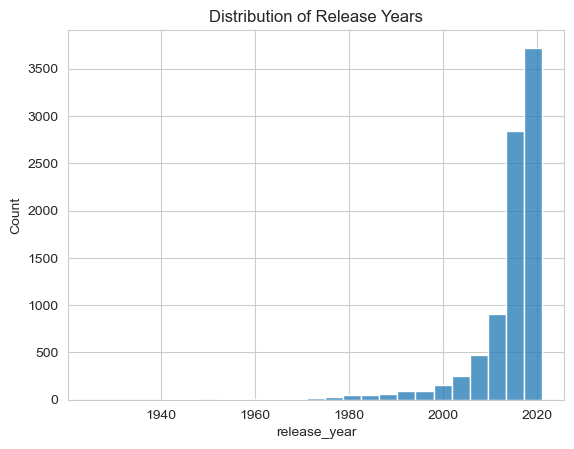

In [189]:
sns.histplot(df['release_year'], bins=25)
plt.title("Distribution of Release Years")
plt.show()

##### Histplot shows how much more content per year is released.

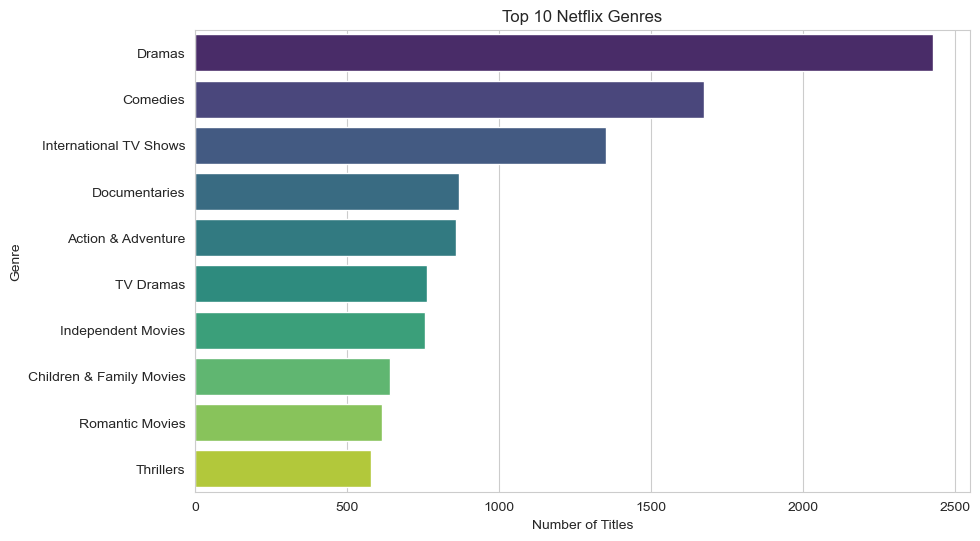

In [190]:
df['genres'] = df['listed_in'].str.split(', ')
df_genres = df.explode('genres')
df_genres = df_genres[df_genres['genres'] != 'International Movies']
top_genres = df_genres['genres'].value_counts().head(10)
plt.figure(figsize=(10,6))
sns.barplot(x=top_genres.values, y=top_genres.index, palette="viridis")
plt.title("Top 10 Netflix Genres")
plt.xlabel("Number of Titles")
plt.ylabel("Genre")
plt.show()

##### Barplot shows what the top 10 genres are and how many items in those categories. 

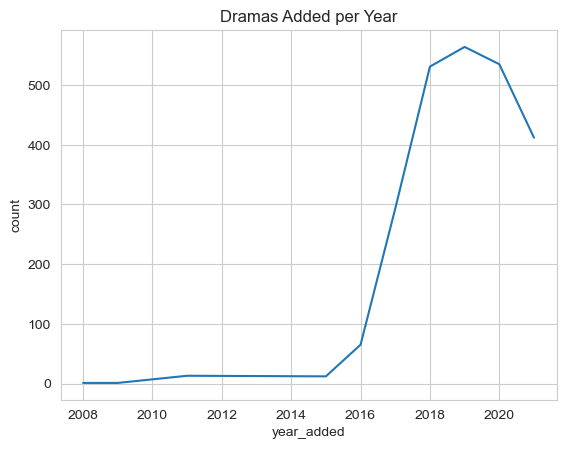

In [191]:
genre_year = df_genres.groupby(['year_added', 'genres']).size().reset_index(name='count')

dramas_trend = genre_year[genre_year['genres'] == 'Dramas']
sns.lineplot(data=dramas_trend, x='year_added', y='count')
plt.title("Dramas Added per Year")
plt.show()

##### Shows Dramas (top 1 genre) added per year.

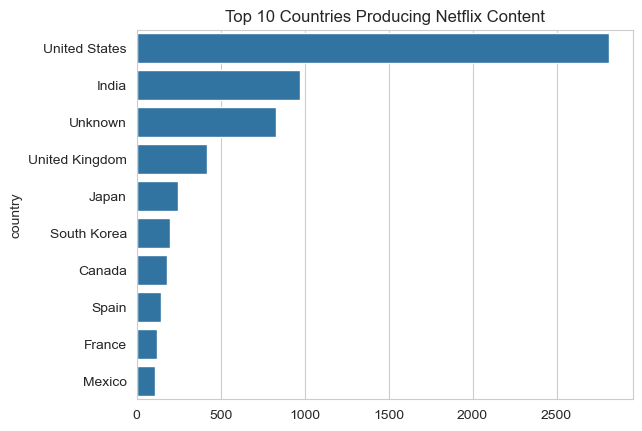

In [192]:
top_countries = df['country'].value_counts().head(10)
sns.barplot(x=top_countries.values, y=top_countries.index)
plt.title("Top 10 Countries Producing Netflix Content")
plt.show()

##### Barplot shows which countries produce most of the content in Netflix.

### Insights

* Releases per year started to grow after 2015 with a peak in 2019.
* Movies dominate the catalog, nearly twice as many as TV Shows.
* Top genres are Dramas, Comedies, and Documentaries (excluding “International Movies”). 
* The USA produces the majority of Netflix content, followed by other countries like the India and the United Kingdom.

